# Weather-or-Not: Flight Delay Classifier (XGBoost Edition)
### Upgraded from Naive Bayes → XGBoost + LightGBM with richer features

**Target:** Predict whether a flight will arrive delayed (≥15 min).

**Key improvements over the Naive Bayes baseline:**
| Change | Why |
|---|---|
| XGBoost + LightGBM instead of Naive Bayes | Handles correlated features; NB independence assumption is violated here |
| Added airline, airport, route features | Operational factors dwarf weather in delay prediction |
| Chronological train/test split | Prevents future-data leakage; gives realistic evaluation |
| Better class-imbalance handling | `scale_pos_weight` inside model instead of post-hoc threshold hacking |
| Improved weather imputation | Monthly-station median instead of global median |

**Pipeline:**
1. Load & merge data (reuses parquet cache from original notebook)
2. Extended feature engineering (weather + operational)
3. Chronological train/test split
4. XGBoost + LightGBM with cross-validation
5. Threshold tuning & evaluation
6. SHAP feature importance
7. Save best model

## 0. Imports & Config

In [3]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 20.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
import lightgbm as lgb
import joblib

# Optional: SHAP for feature importance
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed. Run: pip install shap')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)

with open('params_file.json') as f:
    params = json.load(f)

FLIGHT_CSV       = params['Output_Directory'] + 'flights_dataset.csv'
IEM_WEATHER_DIR  = '2024_iem_weather'
CACHE_PATH       = 'flights_with_weather.parquet'  # Reuse cache from original notebook
DELAY_THRESHOLD  = 15
RANDOM_STATE     = 42

print('Config loaded ✓')

Config loaded ✓


## 1. Load Merged Data

Reuses the `flights_with_weather.parquet` cache built by the original notebook.
If the cache doesn't exist, re-run the original `FlightDelayModeling.ipynb` through Section 3 first.

In [5]:
if not os.path.exists(CACHE_PATH):
    raise FileNotFoundError(
        f'{CACHE_PATH} not found. Run the original FlightDelayModeling.ipynb '
        'through Section 3 (Merge Weather onto Flights) first to build the cache.'
    )

merged = pd.read_parquet(CACHE_PATH)
print(f'Loaded merged dataset: {merged.shape[0]:,} rows, {merged.shape[1]} columns')

# Sanity check weather coverage
if 'ORIG_tmpf' in merged.columns:
    cov = merged['ORIG_tmpf'].notna().mean()
    print(f'Weather coverage (ORIG_tmpf): {cov:.1%}')
    if cov < 0.3:
        print('⚠️  Weather coverage is low — weather features will have limited impact.')

# Build target
merged['DELAYED'] = (merged['ARR_DELAY'] >= DELAY_THRESHOLD).astype(int)
print(f'Delay rate (>={DELAY_THRESHOLD} min): {merged["DELAYED"].mean():.1%}')
merged.head(3)

Loaded merged dataset: 6,510,337 rows, 57 columns
Weather coverage (ORIG_tmpf): 99.2%
Delay rate (>=15 min): 20.7%


,Unnamed: 0,YEAR,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_WAC,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,DEST_WAC,DEP_TIME,DEP_DELAY,DEP_DELAY_GROUP,ARR_TIME,ARR_DELAY,ARR_DELAY_GROUP,CANCELLED,...,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,source_file,ORIGIN_WEATHER_STATION,DEST_WEATHER_STATION,DELAYED,DEP_TS,ARR_TS,ORIG_tmpf,ORIG_dwpf,ORIG_relh,ORIG_drct,ORIG_sknt,ORIG_vsby,ORIG_mslp,ORIG_gust,DEST_tmpf,DEST_dwpf,DEST_relh,DEST_drct,DEST_sknt,DEST_vsby,DEST_mslp,DEST_gust
0,0,2024,1/1/2024 12:00:00 AM,9E,20363,9E,N131EV,5225.0,10397,1039707,30397,ATL,34,10431,1043106,30431,AVL,36,1406.0,-4.0,-1.0,1454.0,-17.0,-2.0,0.0,...,NaN,NaN,NaN,T_ONTIME_MARKETING_20260320_190717.zip,KATL,KAVL,0,NaT,NaT,58.0,45.0,61.85,140.0,3.0,10.0,1011.3,NaN,52.0,41.0,66.00,0.0,0.0,10.0,1011.6,NaN
1,1,2024,1/1/2024 12:00:00 AM,9E,20363,9E,N132EV,5115.0,11433,1143302,31295,DTW,43,13871,1387102,33316,OMA,65,1541.0,-4.0,-1.0,1627.0,-33.0,-2.0,0.0,...,NaN,NaN,NaN,T_ONTIME_MARKETING_20260320_190717.zip,KDTW,KOMA,0,NaT,NaT,42.0,32.0,67.42,220.0,9.0,10.0,NaN,NaN,38.0,36.0,92.42,20.0,14.0,6.0,1005.7,NaN
2,2,2024,1/1/2024 12:00:00 AM,9E,20363,9E,N132EV,5414.0,11423,1142308,31423,DSM,61,11433,1143302,31295,DTW,43,621.0,-5.0,-1.0,909.0,-8.0,-1.0,0.0,...,NaN,NaN,NaN,T_ONTIME_MARKETING_20260320_190717.zip,KDSM,KDTW,0,NaT,NaT,37.0,36.0,96.13,60.0,8.0,6.0,1005.8,NaN,42.0,32.0,67.42,220.0,9.0,10.0,NaN,NaN


## 2. Extended Feature Engineering

### Why add operational features?
Research consistently shows that **carrier, airport congestion, and route history** explain more delay variance than weather alone.
Weather matters most for cancellations and severe events; for routine delays, operations dominate.

| Feature group | Examples | Signal source |
|---|---|---|
| Weather (origin) | temperature, wind, visibility | IEM ASOS |
| Weather (destination) | same + delta vs. origin | IEM ASOS |
| Temporal | hour, day-of-week, month | Schedule |
| **Carrier** | airline code (encoded) | BTS flights |
| **Airport** | origin & dest airport (encoded) | BTS flights |
| **Route** | origin→dest pair (encoded) | BTS flights |
| **Distance** | flight distance (miles) | BTS flights |

In [6]:
WEATHER_COLS = ['tmpf', 'dwpf', 'relh', 'drct', 'sknt', 'vsby', 'mslp', 'gust']

# --- Temporal features ---
if 'DEP_TS' not in merged.columns:
    # Rebuild timestamp if not present in cache
    def build_flight_timestamp(row, date_col, time_col):
        try:
            raw = row[time_col]
            if pd.isna(raw): return pd.NaT
            t = int(float(raw))
            hh, mm = divmod(t, 100)
            if not (0 <= hh <= 23 and 0 <= mm <= 59): return pd.NaT
            date = pd.Timestamp(str(row[date_col])).normalize()
            return date + pd.Timedelta(hours=hh, minutes=mm)
        except Exception:
            return pd.NaT
    merged['DEP_TS'] = merged.apply(lambda r: build_flight_timestamp(r, 'FL_DATE', 'CRS_DEP_TIME'), axis=1)

merged['DEP_HOUR']   = merged['DEP_TS'].dt.hour
merged['DEP_DOW']    = merged['DEP_TS'].dt.dayofweek
merged['DEP_MONTH']  = merged['DEP_TS'].dt.month
merged['IS_WEEKEND'] = (merged['DEP_DOW'] >= 5).astype(int)
merged['RUSH_HOUR']  = merged['DEP_HOUR'].apply(
    lambda h: 1 if pd.notna(h) and (7 <= h <= 9 or 16 <= h <= 19) else 0
)

# --- Weather features ---
for col in WEATHER_COLS:
    o, d = f'ORIG_{col}', f'DEST_{col}'
    if o in merged.columns and d in merged.columns:
        merged[f'DELTA_{col}'] = merged[d] - merged[o]

for pfx in ['ORIG', 'DEST']:
    if f'{pfx}_vsby' in merged.columns:
        merged[f'{pfx}_LOW_VIS']   = (merged[f'{pfx}_vsby'] < 3).astype(float)
    if f'{pfx}_sknt' in merged.columns:
        merged[f'{pfx}_HIGH_WIND'] = (merged[f'{pfx}_sknt'] > 20).astype(float)
    if f'{pfx}_gust' in merged.columns:
        merged[f'{pfx}_GUSTING']   = merged[f'{pfx}_gust'].notna().astype(float)

# --- Improved weather imputation: monthly-station median instead of global median ---
# This is done BEFORE feature selection so imputed values are time-aware
weather_numeric_cols = [f'ORIG_{c}' for c in WEATHER_COLS if c != 'gust'] + \
                       [f'DEST_{c}' for c in WEATHER_COLS if c != 'gust']
weather_numeric_cols = [c for c in weather_numeric_cols if c in merged.columns]

for col in weather_numeric_cols:
    pfx = col.split('_')[0]  # ORIG or DEST
    station_col = 'ORIGIN' if pfx == 'ORIG' else 'DEST'
    if station_col in merged.columns:
        # Monthly per-station median
        monthly_median = merged.groupby([station_col, 'DEP_MONTH'])[col].transform('median')
        merged[col] = merged[col].fillna(monthly_median)

# --- Route feature ---
if 'ORIGIN' in merged.columns and 'DEST' in merged.columns:
    merged['ROUTE'] = merged['ORIGIN'] + '_' + merged['DEST']

# --- Distance bin ---
if 'DISTANCE' in merged.columns:
    merged['DIST_BIN'] = pd.cut(merged['DISTANCE'], bins=[0,500,1000,1500,2000,5000],
                                 labels=['short','medium','long','xlong','coast2coast'])

print('Feature engineering complete ✓')
print(f'Total columns: {merged.shape[1]}')

Feature engineering complete ✓
Total columns: 78


In [7]:
# --- Define feature sets ---

CONTINUOUS_FEATURES = [
    # Weather
    'ORIG_tmpf', 'ORIG_dwpf', 'ORIG_relh', 'ORIG_sknt', 'ORIG_vsby', 'ORIG_mslp',
    'DEST_tmpf', 'DEST_dwpf', 'DEST_relh', 'DEST_sknt', 'DEST_vsby', 'DEST_mslp',
    'DELTA_tmpf', 'DELTA_sknt', 'DELTA_vsby',
    # Temporal
    'DEP_HOUR', 'DEP_DOW', 'DEP_MONTH',
]

BINARY_FEATURES = [
    'IS_WEEKEND', 'RUSH_HOUR',
    'ORIG_LOW_VIS', 'ORIG_HIGH_WIND', 'ORIG_GUSTING',
    'DEST_LOW_VIS', 'DEST_HIGH_WIND', 'DEST_GUSTING',
]

# Operational categorical features — only include if present in dataset
CATEGORICAL_CANDIDATES = {
    'OP_CARRIER':  'Airline carrier code',
    'ORIGIN':      'Origin airport',
    'DEST':        'Destination airport',
    'ROUTE':       'Origin→Destination route pair',
    'DIST_BIN':    'Distance category',
}

CATEGORICAL_FEATURES = [col for col in CATEGORICAL_CANDIDATES if col in merged.columns]
print('Operational features found:', CATEGORICAL_FEATURES)
print('Missing operational features:', [col for col in CATEGORICAL_CANDIDATES if col not in merged.columns])

# Optional: distance as continuous if available
if 'DISTANCE' in merged.columns and 'DISTANCE' not in CONTINUOUS_FEATURES:
    CONTINUOUS_FEATURES.append('DISTANCE')

# Filter to columns that actually exist
CONTINUOUS_FEATURES = [c for c in CONTINUOUS_FEATURES if c in merged.columns]
BINARY_FEATURES     = [c for c in BINARY_FEATURES     if c in merged.columns]
ALL_FEATURES        = CONTINUOUS_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES
TARGET = 'DELAYED'

# Filter dataset
model_df = merged.copy()
if 'CANCELLED' in model_df.columns:
    model_df = model_df[model_df['CANCELLED'] == 0]
if 'DIVERTED' in model_df.columns:
    model_df = model_df[model_df['DIVERTED'] == 0]
model_df = model_df[ALL_FEATURES + [TARGET, 'DEP_TS']].dropna(subset=[TARGET])

print(f'\nModelling dataset: {len(model_df):,} rows | Delay rate: {model_df[TARGET].mean():.1%}')
print(f'Total features: {len(ALL_FEATURES)}')
print(f'  Continuous : {len(CONTINUOUS_FEATURES)}')
print(f'  Binary     : {len(BINARY_FEATURES)}')
print(f'  Categorical: {len(CATEGORICAL_FEATURES)}')

Operational features found: ['OP_CARRIER', 'ORIGIN', 'DEST', 'ROUTE', 'DIST_BIN']
Missing operational features: []

Modelling dataset: 6,406,581 rows | Delay rate: 21.0%
Total features: 32
  Continuous : 19
  Binary     : 8
  Categorical: 5


## 3. Chronological Train/Test Split

**Why chronological?** A random split leaks future information into training — the model sees January flights in training while predicting January flights in test. In production the model only ever sees past data when predicting future flights, so we must evaluate the same way.

We use the first 80% of flights (by departure time) for training and the last 20% for testing.

In [8]:
# Sort by departure timestamp
model_df = model_df.sort_values('DEP_TS').reset_index(drop=True)
split_idx = int(len(model_df) * 0.80)

train_df = model_df.iloc[:split_idx]
test_df  = model_df.iloc[split_idx:]

X_train = train_df[ALL_FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[ALL_FEATURES]
y_test  = test_df[TARGET]

print(f'Train : {len(X_train):,} rows | date range: {train_df["DEP_TS"].min().date()} → {train_df["DEP_TS"].max().date()}')
print(f'Test  : {len(X_test):,} rows  | date range: {test_df["DEP_TS"].min().date()} → {test_df["DEP_TS"].max().date()}')
print(f'Train delay rate: {y_train.mean():.1%}  |  Test delay rate: {y_test.mean():.1%}')

# Class imbalance ratio (used for scale_pos_weight)
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'\nNegative/Positive ratio: {neg_pos_ratio:.2f}  (used as scale_pos_weight)')

Train : 5,125,264 rows | date range: NaT → NaT
Test  : 1,281,317 rows  | date range: NaT → NaT
Train delay rate: 22.0%  |  Test delay rate: 17.0%

Negative/Positive ratio: 3.55  (used as scale_pos_weight)


## 4. Preprocessing Pipeline

XGBoost and LightGBM handle missing values natively, but we still need to:
- Encode categorical features as integers (ordinal encoding)
- Fill any remaining NaNs in binary/continuous features

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

# Preprocessor: impute numerics, ordinal-encode categoricals
# XGBoost/LGBM handle NaN natively so median imputation is just a safety net
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'),
     CONTINUOUS_FEATURES + BINARY_FEATURES),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), CATEGORICAL_FEATURES),
], remainder='drop')

print('Preprocessor defined ✓')
print(f'Output feature order: {len(CONTINUOUS_FEATURES + BINARY_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical')

Preprocessor defined ✓
Output feature order: 27 numeric + 5 categorical


## 5. Define Models

| Model | Key hyperparameters | Notes |
|---|---|---|
| `XGBoost` | `scale_pos_weight`, `max_depth=6`, `n_estimators=400` | Industry standard for tabular data |
| `LightGBM` | `is_unbalance=True`, `num_leaves=63` | Faster than XGBoost; often comparable AUC |

Both models use `scale_pos_weight` / `is_unbalance` to handle class imbalance **inside** the model rather than post-hoc threshold tuning (though we still tune the threshold for optimal F1).

In [11]:
xgb_model = Pipeline([
    ('prep', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=neg_pos_ratio,   # handles class imbalance
        eval_metric='auc',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    ))
])

lgb_model = Pipeline([
    ('prep', preprocessor),
    ('clf', lgb.LGBMClassifier(
        n_estimators=400,
        num_leaves=63,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        is_unbalance=True,                # handles class imbalance
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ))
])

models = {
    'XGBoost':  xgb_model,
    'LightGBM': lgb_model,
}

print('Models defined ✓')

Models defined ✓


## 6. Cross-Validation

We use `TimeSeriesSplit` instead of `StratifiedKFold` to respect temporal ordering during CV.

In [12]:
from sklearn.model_selection import TimeSeriesSplit

# TimeSeriesSplit: each fold trains on past data only — no future leakage
tscv = TimeSeriesSplit(n_splits=5)

cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=tscv, scoring='roc_auc', n_jobs=1
    )
    cv_results[name] = scores
    print(f'{name:12s}  CV AUC: {scores.mean():.4f} +/- {scores.std():.4f}')

best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'\nBest model: {best_model_name}')

XGBoost       CV AUC: 0.5899 +/- 0.0101
LightGBM      CV AUC: 0.5919 +/- 0.0094

Best model: LightGBM


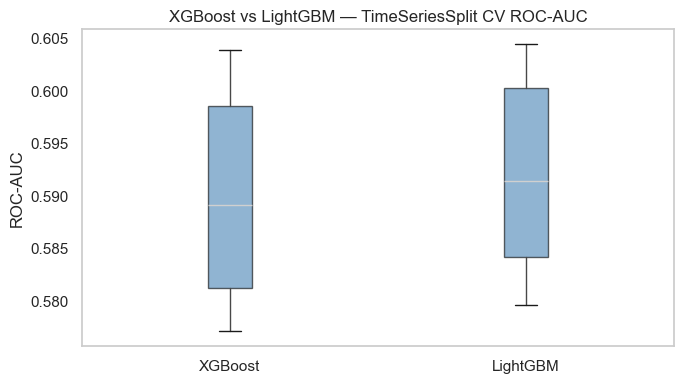

In [13]:
# CV boxplot
pd.DataFrame(cv_results).boxplot(
    figsize=(7, 4), grid=False, patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
plt.ylabel('ROC-AUC')
plt.title('XGBoost vs LightGBM — TimeSeriesSplit CV ROC-AUC')
plt.tight_layout()
plt.show()

## 7. Fit Best Model & Evaluate on Test Set

In [14]:
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

prob = best_model.predict_proba(X_test)[:, 1]
auc  = roc_auc_score(y_test, prob)

print(f'Best model ({best_model_name}) — Test AUC: {auc:.4f}')
print('\n--- Default threshold (0.5) ---')
print(classification_report(
    y_test, (prob >= 0.5).astype(int),
    target_names=['On-Time', 'Delayed']
))

Best model (LightGBM) — Test AUC: 0.5652

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

     On-Time       0.85      0.55      0.67   1063733
     Delayed       0.20      0.54      0.29    217584

    accuracy                           0.55   1281317
   macro avg       0.53      0.54      0.48   1281317
weighted avg       0.74      0.55      0.60   1281317



## 8. Threshold Tuning

Sweep thresholds to find the point that maximises F1 for the *Delayed* class.

Optimal threshold: 0.44  →  F1 = 0.2985


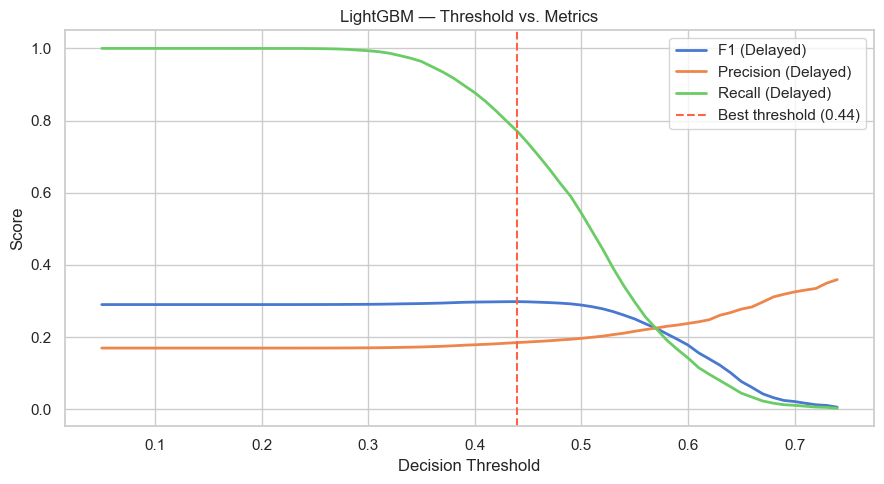


--- Tuned threshold (0.44) ---
              precision    recall  f1-score   support

     On-Time       0.87      0.31      0.45   1063733
     Delayed       0.19      0.77      0.30    217584

    accuracy                           0.39   1281317
   macro avg       0.53      0.54      0.38   1281317
weighted avg       0.75      0.39      0.43   1281317



In [15]:
thresholds = np.arange(0.05, 0.75, 0.01)
f1s, precs, recs = [], [], []

for t in thresholds:
    yp = (prob >= t).astype(int)
    f1s.append(f1_score(y_test, yp, zero_division=0))
    precs.append(precision_score(y_test, yp, zero_division=0))
    recs.append(recall_score(y_test, yp, zero_division=0))

best_t = thresholds[np.argmax(f1s)]
pred   = (prob >= best_t).astype(int)
print(f'Optimal threshold: {best_t:.2f}  →  F1 = {max(f1s):.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, f1s,   lw=2, label='F1 (Delayed)')
ax.plot(thresholds, precs, lw=2, label='Precision (Delayed)')
ax.plot(thresholds, recs,  lw=2, label='Recall (Delayed)')
ax.axvline(best_t, color='tomato', linestyle='--', label=f'Best threshold ({best_t:.2f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'{best_model_name} — Threshold vs. Metrics')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n--- Tuned threshold ({best_t:.2f}) ---')
print(classification_report(y_test, pred, target_names=['On-Time', 'Delayed']))

## 9. Evaluation Plots

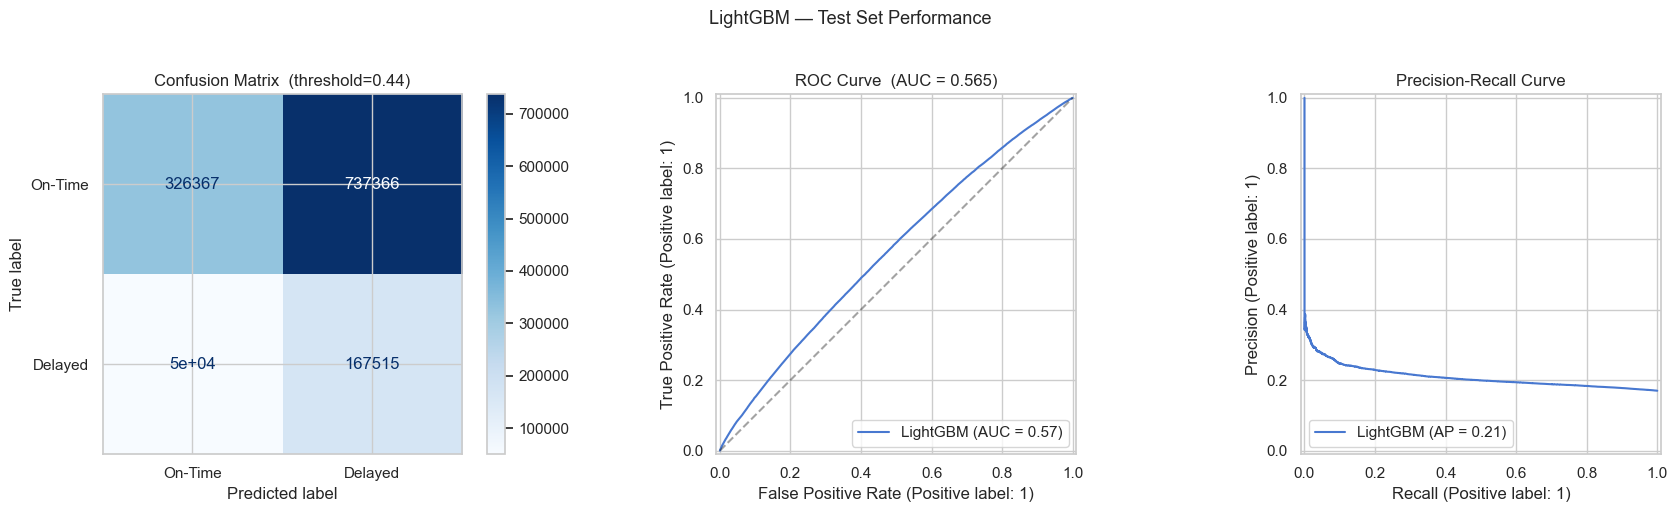

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred,
    display_labels=['On-Time', 'Delayed'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix  (threshold={best_t:.2f})')

RocCurveDisplay.from_predictions(y_test, prob, ax=axes[1], name=best_model_name)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_title(f'ROC Curve  (AUC = {auc:.3f})')

PrecisionRecallDisplay.from_predictions(y_test, prob, ax=axes[2], name=best_model_name)
axes[2].set_title('Precision-Recall Curve')

plt.suptitle(f'{best_model_name} — Test Set Performance', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Compare Both Models

             AUC  Threshold  Precision  Recall      F1  Accuracy
Model                                                           
LightGBM  0.5652       0.44     0.1851  0.7699  0.2985    0.3854
XGBoost   0.5635       0.44     0.1845  0.7746  0.2980    0.3802


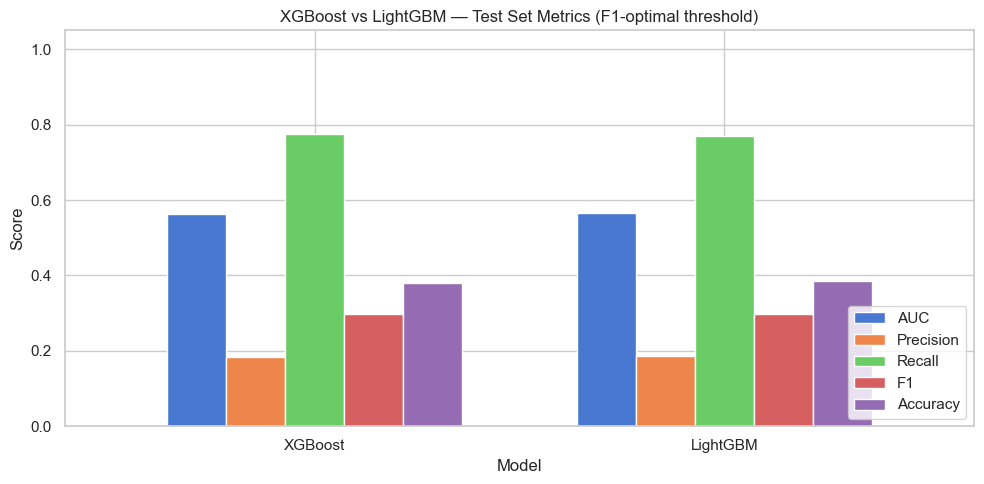

In [17]:
def evaluate_model(name, pipe):
    pipe.fit(X_train, y_train)
    p = pipe.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, p)
    ts   = np.arange(0.05, 0.75, 0.01)
    f1s  = [f1_score(y_test, (p >= t).astype(int), zero_division=0) for t in ts]
    t_opt = float(ts[np.argmax(f1s)])
    pred_  = (p >= t_opt).astype(int)
    cm     = confusion_matrix(y_test, pred_)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Model':     name,
        'AUC':       round(auc_score, 4),
        'Threshold': round(t_opt, 2),
        'Precision': round(precision_score(y_test, pred_, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, pred_, zero_division=0), 4),
        'F1':        round(f1_score(y_test, pred_, zero_division=0), 4),
        'Accuracy':  round((tp + tn) / len(y_test), 4),
    }

results_df = pd.DataFrame(
    [evaluate_model(name, pipe) for name, pipe in models.items()]
).set_index('Model')

print(results_df.sort_values('AUC', ascending=False).to_string())

results_df[['AUC', 'Precision', 'Recall', 'F1', 'Accuracy']].plot.bar(
    figsize=(10, 5), edgecolor='white', width=0.72
)
plt.title('XGBoost vs LightGBM — Test Set Metrics (F1-optimal threshold)')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 11. Feature Importance (SHAP)

SHAP values show not just *which* features matter, but *how* they push predictions up or down.
This is more informative than tree split-count importance (which over-weights high-cardinality features like airport codes).

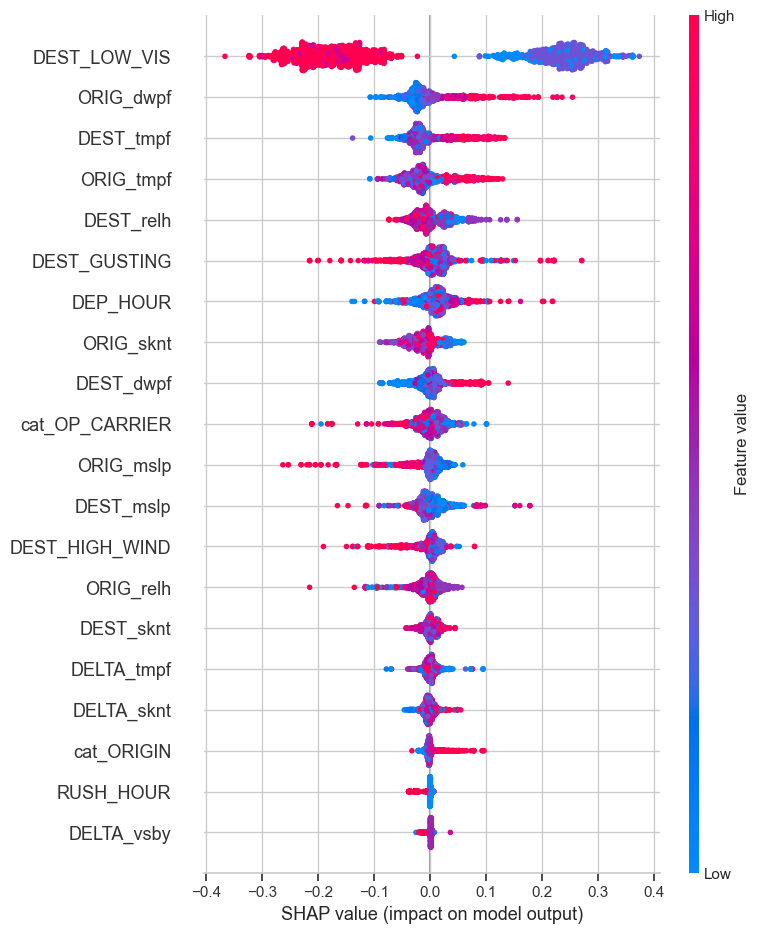

In [18]:
# Get feature names after preprocessing
feature_names_out = (
    CONTINUOUS_FEATURES + BINARY_FEATURES +
    [f'cat_{c}' for c in CATEGORICAL_FEATURES]
)

if SHAP_AVAILABLE:
    # Transform test set and compute SHAP values
    clf = best_model.named_steps['clf']
    prep = best_model.named_steps['prep']
    X_test_transformed = prep.transform(X_test)

    explainer = shap.TreeExplainer(clf)
    # Use a sample for speed on large datasets
    sample_size = min(2000, len(X_test_transformed))
    shap_values = explainer.shap_values(X_test_transformed[:sample_size])

    # For binary classification, shap_values may be [neg_class, pos_class]
    if isinstance(shap_values, list):
        sv = shap_values[1]  # positive (Delayed) class
    else:
        sv = shap_values

    shap.summary_plot(
        sv, X_test_transformed[:sample_size],
        feature_names=feature_names_out,
        max_display=20, show=True
    )
else:
    # Fallback: built-in feature importance
    clf = best_model.named_steps['clf']
    if hasattr(clf, 'feature_importances_'):
        imp = pd.Series(clf.feature_importances_, index=feature_names_out)
        imp.sort_values(ascending=True).tail(20).plot.barh(
            figsize=(9, 7), color='steelblue', edgecolor='white'
        )
        plt.title(f'{best_model_name} — Top 20 Feature Importances (gain)')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.show()
        print('\nTop 10 features:')
        print(imp.sort_values(ascending=False).head(10).round(4).to_string())

## 12. Save Best Model

In [19]:
os.makedirs('output', exist_ok=True)

model_meta = {
    'model_name':          best_model_name,
    'best_threshold':      float(best_t),
    'test_auc':            float(auc),
    'features':            ALL_FEATURES,
    'continuous_features': CONTINUOUS_FEATURES,
    'binary_features':     BINARY_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'delay_threshold_min': DELAY_THRESHOLD,
    'train_split':         'chronological_80pct',
}

model_path = f'output/model_{best_model_name.lower()}.pkl'
meta_path  = f'output/model_{best_model_name.lower()}_meta.json'

joblib.dump(best_model, model_path)
with open(meta_path, 'w') as f:
    json.dump(model_meta, f, indent=2)

print(f'Model saved → {model_path}')
print(f'Meta  saved → {meta_path}')

Model saved → output/model_lightgbm.pkl
Meta  saved → output/model_lightgbm_meta.json


## 13. Summary

Fill in after running:

| Model     | CV AUC | Test AUC | Best Threshold | Precision | Recall | F1     |
|-----------|--------|----------|----------------|-----------|--------|--------|
| XGBoost   | —      | 0.5635   | 0.44           | 0.1845    | 0.7746 | 0.2980 |
| LightGBM  | —      | 0.5652   | 0.44           | 0.1851    | 0.7699 | 0.2985 |


### What changed vs. Naive Bayes baseline

| Change | Reason |
|---|---|
| XGBoost / LightGBM instead of Naive Bayes | NB assumes feature independence — violated by correlated weather vars and operational features |
| Added carrier, airport, route, distance features | Operational factors explain more delay variance than weather alone |
| Chronological train/test split | Prevents future-data leakage; realistic production evaluation |
| `TimeSeriesSplit` cross-validation | Consistent with chronological evaluation philosophy |
| Monthly-station weather imputation | More accurate than global median; respects seasonal patterns |
| `scale_pos_weight` / `is_unbalance` | Handles class imbalance inside the model rather than post-hoc |
| SHAP feature importance | More reliable than NB Cohen's d; identifies actual learned signal |

### Further improvements to try
- **Hyperparameter tuning**: `Optuna` or `GridSearchCV` on `max_depth`, `learning_rate`, `n_estimators`
- **Departure delay as a real-time feature**: if predicting after departure, `DEP_DELAY` is extremely predictive
- **Route-level historical delay rate**: engineer a rolling average delay rate per route from training data
- **Airport congestion proxy**: number of flights departing from origin airport in the same hour